In [1]:
import os
import sys
import argparse

import matplotlib.pyplot as plt

from data import *
from utils import *
from datetime import datetime

sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Disentanglement'))
sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Accuracy'))

from DCI import compute_dci, report_dci
from IRS import compute_irs_from_multihot_labels, compute_irs
from BA import oh_binary_accuracy

In [2]:
parser = argparse.ArgumentParser(description='Gen-RKM Model')

parser.add_argument('--N', type=int, default=100, help='Total # of samples')
parser.add_argument('--mb_size', type=int, default=100, help='Mini-batch size. See utils.py')
parser.add_argument('--h_dim', type=int, default=10, help='Dim of latent vector')
parser.add_argument('--capacity', type=int, default=32, help='Capacity of network. See utils.py')
parser.add_argument('--x_fdim', type=int, default=128, help='Input x_fdim. See utils.py')
parser.add_argument('--y_fdim', type=int, default=20, help='Input y_fdim. See utils.py')
parser.add_argument('--c_accu', type=float, default=100, help='Input weight on recons_error')

# Training Settings =============================
parser.add_argument('--lr', type=float, default=1e-4, help='Input learning rate for optimizer')
parser.add_argument('--max_epochs', type=int, default=2000, help='Input max_epoch for cut-off')
parser.add_argument('--device', type=str, default='cpu', help='Device type: cuda or cpu')
parser.add_argument('--workers', type=int, default=0, help='# of workers for dataloader')
parser.add_argument('--shuffle', type=bool, default=False, help='shuffle dataset: true or false')

opt, _ = parser.parse_known_args()

In [3]:
xtrain, ipVec_dim, nChannels = get_mnist_dataloader(args=opt)

In [4]:
ct = time.strftime("%Y%m%d-%H%M")
dirs = create_dirs(ct=ct)
dirs.create()

In [5]:
def kPCA(X, Y):
    # print('Shapes of KPCA input:', X.shape, Y.shape)
    a = torch.mm(X, torch.t(X)) + torch.mm(Y, torch.t(Y))
    nh1 = a.size(0)
    oneN = torch.div(torch.ones(nh1, nh1), nh1).double().to(opt.device)
    a = a - torch.mm(oneN, a) - torch.mm(a, oneN) + torch.mm(torch.mm(oneN, a), oneN)  # centering
    h, s, _ = torch.svd(a, some=False)
    return h[:, :opt.h_dim], s

In [6]:
def rkm_loss(output1, X, output2, Y):
    h, s = kPCA(output1, output2)
    U = torch.mm(output1.t(), h)
    V = torch.mm(output2.t(), h)

    x_tilde = net3(torch.mm(h, U.t()))
    y_logits = net4(torch.mm(h, V.t()))   # treat as logits (no softmax here)

    # Costs
    f1 = torch.trace(torch.mm(torch.mm(output1, U), h.t())) + torch.trace(
         torch.mm(torch.mm(output2, V), h.t()))
    f2 = 0.5 * torch.trace(torch.mm(h, torch.mm(torch.diag(s[:opt.h_dim]), h.t())))
    f3 = 0.5 * (torch.trace(torch.mm(U.t(), U)) + torch.trace(torch.mm(V.t(), V)))

    # Reconstruction losses
    mse = torch.nn.MSELoss()
    img_loss = mse(x_tilde.view(-1, ipVec_dim), X.view(-1, ipVec_dim))

    # Label loss: supports Y as one-hot (B,10) or indices (B,)
    if Y.dim() == 2 and Y.size(-1) == 10:
        y_idx = Y.argmax(dim=1).long()
    else:
        y_idx = Y.long().view(-1)

    ce = torch.nn.CrossEntropyLoss()
    lbl_loss = ce(y_logits.view(-1, 10), y_idx)

    f4 = img_loss + lbl_loss

    loss = -f1 + f3 + f2 + 0.5 * (-f1 + f3 + f2) ** 2 + opt.c_accu * f4
    return loss

In [7]:
net1 = Net1().double().to(opt.device)
net2 = Net2().double().to(opt.device)
net3 = Net3().double().to(opt.device)
net4 = Net4().double().to(opt.device)

In [8]:
params = list(net1.parameters()) + list(net3.parameters()) + list(net2.parameters()) + list(net4.parameters())
optimizer = torch.optim.Adam(params, lr=opt.lr, weight_decay=0)

In [9]:
# l_cost = 6  # Costs from where checkpoints will be saved
# t = 1
# cost = np.inf  # Initialize cost
# start = datetime.now()
# while cost > 0.2 and t <= opt.max_epochs:  # run epochs until convergence
#     avg_loss = 0
#     for i, (datax, datay) in enumerate(xtrain):
#         if i < math.ceil(opt.N / opt.mb_size):
#             datax, datay = datax.to(opt.device), datay.to(opt.device)
#             output1 = net1(datax)
#             output2 = net2(datay)

#             loss = rkm_loss(output1, datax, output2, datay)

#             optimizer.zero_grad()
#             loss.backward()
#             optimizer.step()
#             avg_loss += loss.detach().cpu().numpy()
#         else:
#             break
#     cost = avg_loss

#     # Remember lowest cost and save checkpoint
#     is_best = cost < l_cost
#     l_cost = min(cost, l_cost)

#     dirs.save_checkpoint({
#         'epochs': t + 1,
#         'net1_state_dict': net1.state_dict(),
#         'net3_state_dict': net3.state_dict(),
#         'net2_state_dict': net2.state_dict(),
#         'net4_state_dict': net4.state_dict(),
#         'l_cost': l_cost,
#         'optimizer': optimizer.state_dict()}, is_best)
#     print(t, cost)
#     t += 1
# print('Finished Training in: {}. Lowest cost: {}'.format(str(datetime.now() - start), l_cost))

In [10]:
# if os.path.exists('cp/{}'.format(dirs.dircp)):
#     sd_mdl = torch.load('cp/{}'.format(dirs.dircp), weights_only=False)
#     net1.load_state_dict(sd_mdl['net1_state_dict'])
#     net3.load_state_dict(sd_mdl['net3_state_dict'])
#     net2.load_state_dict(sd_mdl['net2_state_dict'])
#     net4.load_state_dict(sd_mdl['net4_state_dict'])

# U, V, h, s = final_compute(opt, net1, net2, kPCA)

In [11]:
# torch.save({'net1': net1,
#             'net3': net3,
#             'net2': net2,
#             'net4': net4,

#             'net1_state_dict': net1.state_dict(),
#             'net3_state_dict': net3.state_dict(),
#             'net2_state_dict': net2.state_dict(),
#             'net4_state_dict': net4.state_dict(),

#             'datax': datax,
#             'datay': datay,

#             'h': h,
#             'opt': opt, 's': s, 'U': U, 'V': V}, 'out/{}'.format(dirs.dirout))

In [12]:
model = torch.load('out/2000.tar', weights_only=False)

U = model['U']
V = model['V']
h = model['h']
s = model['s']

net1 = model['net1']
net2 = model['net2']
net3 = model['net3']
net4 = model['net4']

datax = model['datax']
datay = model['datay']

## Visual Inspection

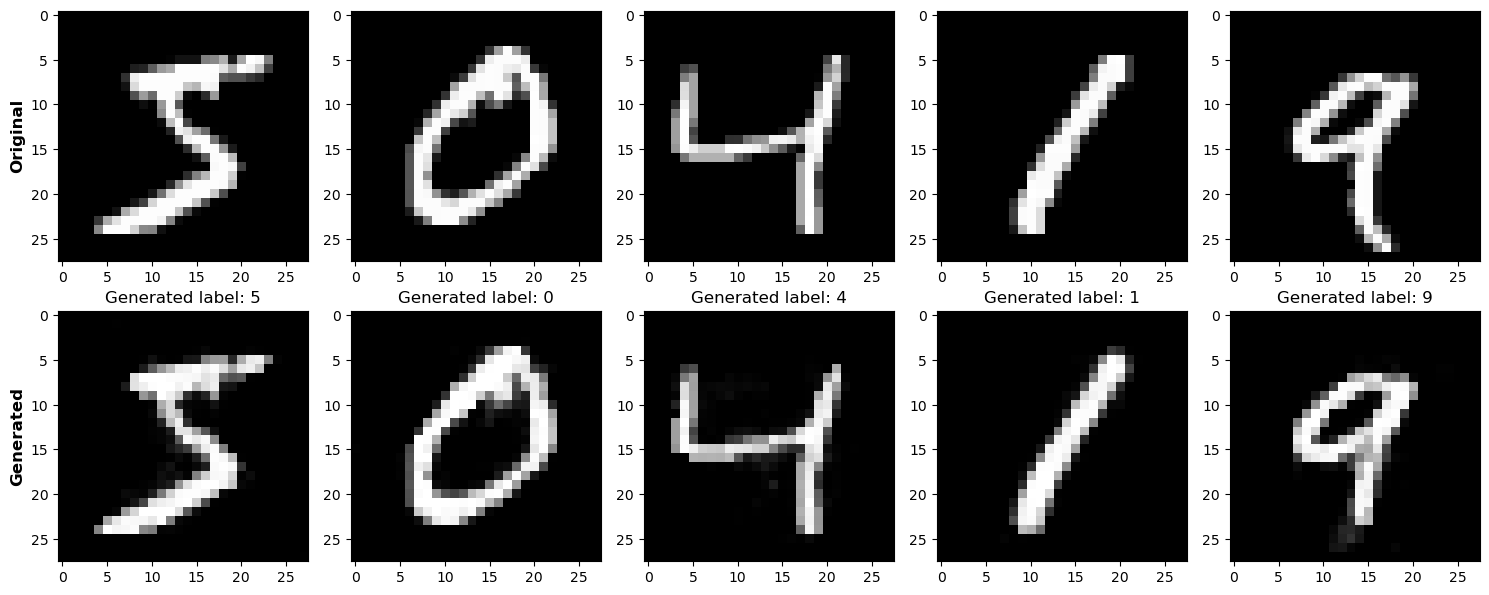

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for idx in range(5):
    h_target = h[idx, :]

    z_digit = torch.mv(U, h_target).unsqueeze(0)
    z_label = torch.mv(V, h_target).unsqueeze(0)

    digit = net3(z_digit).view(28, 28).detach().cpu().numpy()
    label = net4(z_label).view(-1).detach().cpu().numpy().argmax()
    
    axes[0, 0].set_ylabel('Original', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Generated', fontsize=12, fontweight='bold')

    axes[0, idx].imshow(xtrain.dataset.data[idx].view(28, 28), cmap='gray')

    axes[1, idx].imshow(digit, cmap='gray')
    axes[1, idx].set_title('Generated label: {}'.format(label))


plt.tight_layout()
plt.show()

## Evaluation

In [14]:
recon_loss = torch.nn.MSELoss(reduction='mean')

net1.eval()
net2.eval()
net3.eval()
net4.eval()

digit_loss_sum = 0.
label_loss_sum = 0.
loss_sum = 0.
n = 0

with torch.no_grad():
    for i, (datax, datay) in enumerate(xtrain):
        datax = datax.to(opt.device)
        datay = datay.to(opt.device)

        x_tilde = net3(net1(datax))
        y_tilde = net4(net2(datay))

        digit_loss = recon_loss(x_tilde.view(-1, ipVec_dim), datax.view(-1, ipVec_dim))
        label_loss = 1 - oh_binary_accuracy(datay.cpu().numpy(), y_tilde.view(-1, 10).cpu().numpy())

        digit_loss_sum += digit_loss.item()
        label_loss_sum += label_loss.item()

        loss_sum += (digit_loss + label_loss).item() / 2
        n += 1

digit_loss = digit_loss_sum / n
label_loss = label_loss_sum / n
total_loss = loss_sum / n

print("Total Loss:", total_loss)
print("Digit Reconstruction Loss:", digit_loss)
print("Label Loss:", label_loss)

Total Loss: 0.15535209665227753
Digit Reconstruction Loss: 0.12283752663788827
Label Loss: 0.18786666666666688


## Disentanglement

In [15]:
Cs = []
Zs = []

with torch.no_grad():
    for i, (datax, datay) in enumerate(xtrain):
        datax = datax.to(opt.device)
        datay = datay.to(opt.device)
        
        c_im = net1(datax).cpu().numpy()
        
        Cs.append(c_im)
        Zs.append(datay.cpu().numpy())

C = np.concatenate(Cs, axis=0)[:, :28]
Z = np.concatenate(Zs, axis=0)

factor_types = ["discrete"] * 10

In [16]:
res = compute_dci(C, Z, factor_types, probe="lasso")
report_dci(res, title='Combined DCI Scores')

--- Combined DCI Scores ---
 > Disentanglement: 0.1401
 > Completeness: 0.1031
 > Informativeness: 0.9566


- Low D & C -> Did not to learn to store digits based on value, it **organized its latent space around other factors**
- High I -> The representation did store the digits wellI men

-> Other scores must be used

In [17]:
irs_results = compute_irs(C, Z)

print(f'--- IRS Scores ---')
print(f' > IRS Disentanglement: {round(irs_results["IRS"], 4)}')

--- IRS Scores ---
 > IRS Disentanglement: 0.5503
